In [1]:
from collections import defaultdict
from scipy import stats
from scipy.stats import erlang, expon, norm 
from itertools import product, combinations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import time # benchmarking

# User Defined Modules
import Graph

#### Extracting Global Time From Matrix?

# Tasks:

- [x] Make infect time histogram
- [x] Make path histogram
- [x] Test Random Graphs, with n nodes, 1 is src and n is end, check if graph is connected
    - [x] ER-model, parameterize n and p, 
    - [x] if connected run 1000+ simulations
        - [x] overall connected, we don't wnat to run simulations on small components
        - [x] graph is connect if laplacian rank is n-1, manually create 1x1 adjacency and degree matricies?, more efficient than bfs?
- [x] may need to bench bfs compared to laplacian or just checking connectedness at graph initalization
    - Generally weary of having to create 2 new data structures just to calculate one thig
- [x] compact adjacency matrix (don't print literal name of RV)
- [ ] Pythonize code
    - [ ] organize code layout
    - [ ] kwarg utilization
- [ ] Input data like Devlin's
    - [ ] format down, just need to support other distributions
    - [ ] copy `EdgeDistribution.py` from Devlin's repo?
- [ ] Distribution method like Devlin's 
    - [ ] may use Devlin's method of separate class resolver
    - [ ] Generalize Edge Distribtion assignment (custom CDFS)
        - [ ] can extend Devlin's edge resolver class to allow for custom cdfs via scipy.stats.rv
- [ ] ER part 2 
    - [x] Singleton nodes are relevant in connectivity
    - [x] allow for predefined dict of edge weights
    - [x] verify erdos-reiygni
    - [x] have trials with both fixed Gnp and 
    - [x] have trials with resimulated Gnp
        - [ ] fix cycle edge case

# Generality

How general is Graph Class implement:
- Multiple Src
- Single dst 
    - path construction does not check which dst to construct paths from
        - ie it expects a single dst as input
    - iteration stops once a single dst is infected
- $\exp(\lambda = 1)$ edge dst
- Lazy eval of edges
- Nodes have arbitrary labels

How general is EPR implement:
- Graph class can handle directedness or not
- Nodes can not have different dst or dst not exp(1)
- Our model can not have isolated nodes, only isolated connect components

Laplacian Check:
- No approach to "in-degree" vs "out-degree" issue
    - in-degree (technically what I'm using rn) takes column sums for degree
    - out-degree takes row sums for degree
- Counting rows

Erdos-Reyni:
- Our varied ER simulation assumes we are strictly enforcing connectivity

In [2]:
exp_t = lambda t: 1 - np.e**(-t)

edge_set = {
    "1,2": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "1,3": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "2,4": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "2,5": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "3,6": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "4,5": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "4,6": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
}

g = Graph.Graph(edge_set)

In [3]:
g._adjency_matrix

,1,2,3,4,5,6
1,inf,<scipy...,<scipy...,inf,inf,inf
2,<scipy...,inf,inf,<scipy...,<scipy...,inf
3,<scipy...,inf,inf,inf,inf,<scipy...
4,inf,<scipy...,inf,inf,<scipy...,<scipy...
5,inf,<scipy...,inf,<scipy...,inf,inf
6,inf,inf,<scipy...,<scipy...,inf,inf


In [4]:
g._adjency_matrix.loc['1','1']

inf

In [5]:
g.is_connected_laplacian()

np.True_

In [6]:
((g._adjency_matrix.loc[np.array(['1','2'])] == np.inf).all()).all()

np.False_

#### Note: Columns don't actually do a good job of differentiating if a column is a string or int

In [7]:
g.reset_simulation()
g._adjency_matrix.where(g._adjency_matrix == np.inf, 1)

,1,2,3,4,5,6
1,inf,1,1,inf,inf,inf
2,1,inf,inf,1,1,inf
3,1,inf,inf,inf,inf,1
4,inf,1,inf,inf,1,1
5,inf,1,inf,1,inf,inf
6,inf,inf,1,1,inf,inf


In [8]:
t = g.simulate_gossip_rv('1','6', log=False)
path = g.construct_path('1', '6')
display(path)
print(f"Time: {t}")

['6', '3', '1']

Time: 0.8448095617925603


In [9]:
g._adjency_matrix

,1,2,3,4,5,6
1,inf,inf,inf,inf,inf,inf
2,inf,inf,inf,8.818552,inf,inf
3,inf,inf,inf,inf,inf,inf
4,inf,8.818552,inf,inf,1.360825,<scipy...
5,inf,inf,inf,1.360825,inf,inf
6,inf,inf,inf,<scipy...,inf,inf


In [10]:
g.reset_data()
g.reset_simulation()
g.simulation_trial('1', '6')

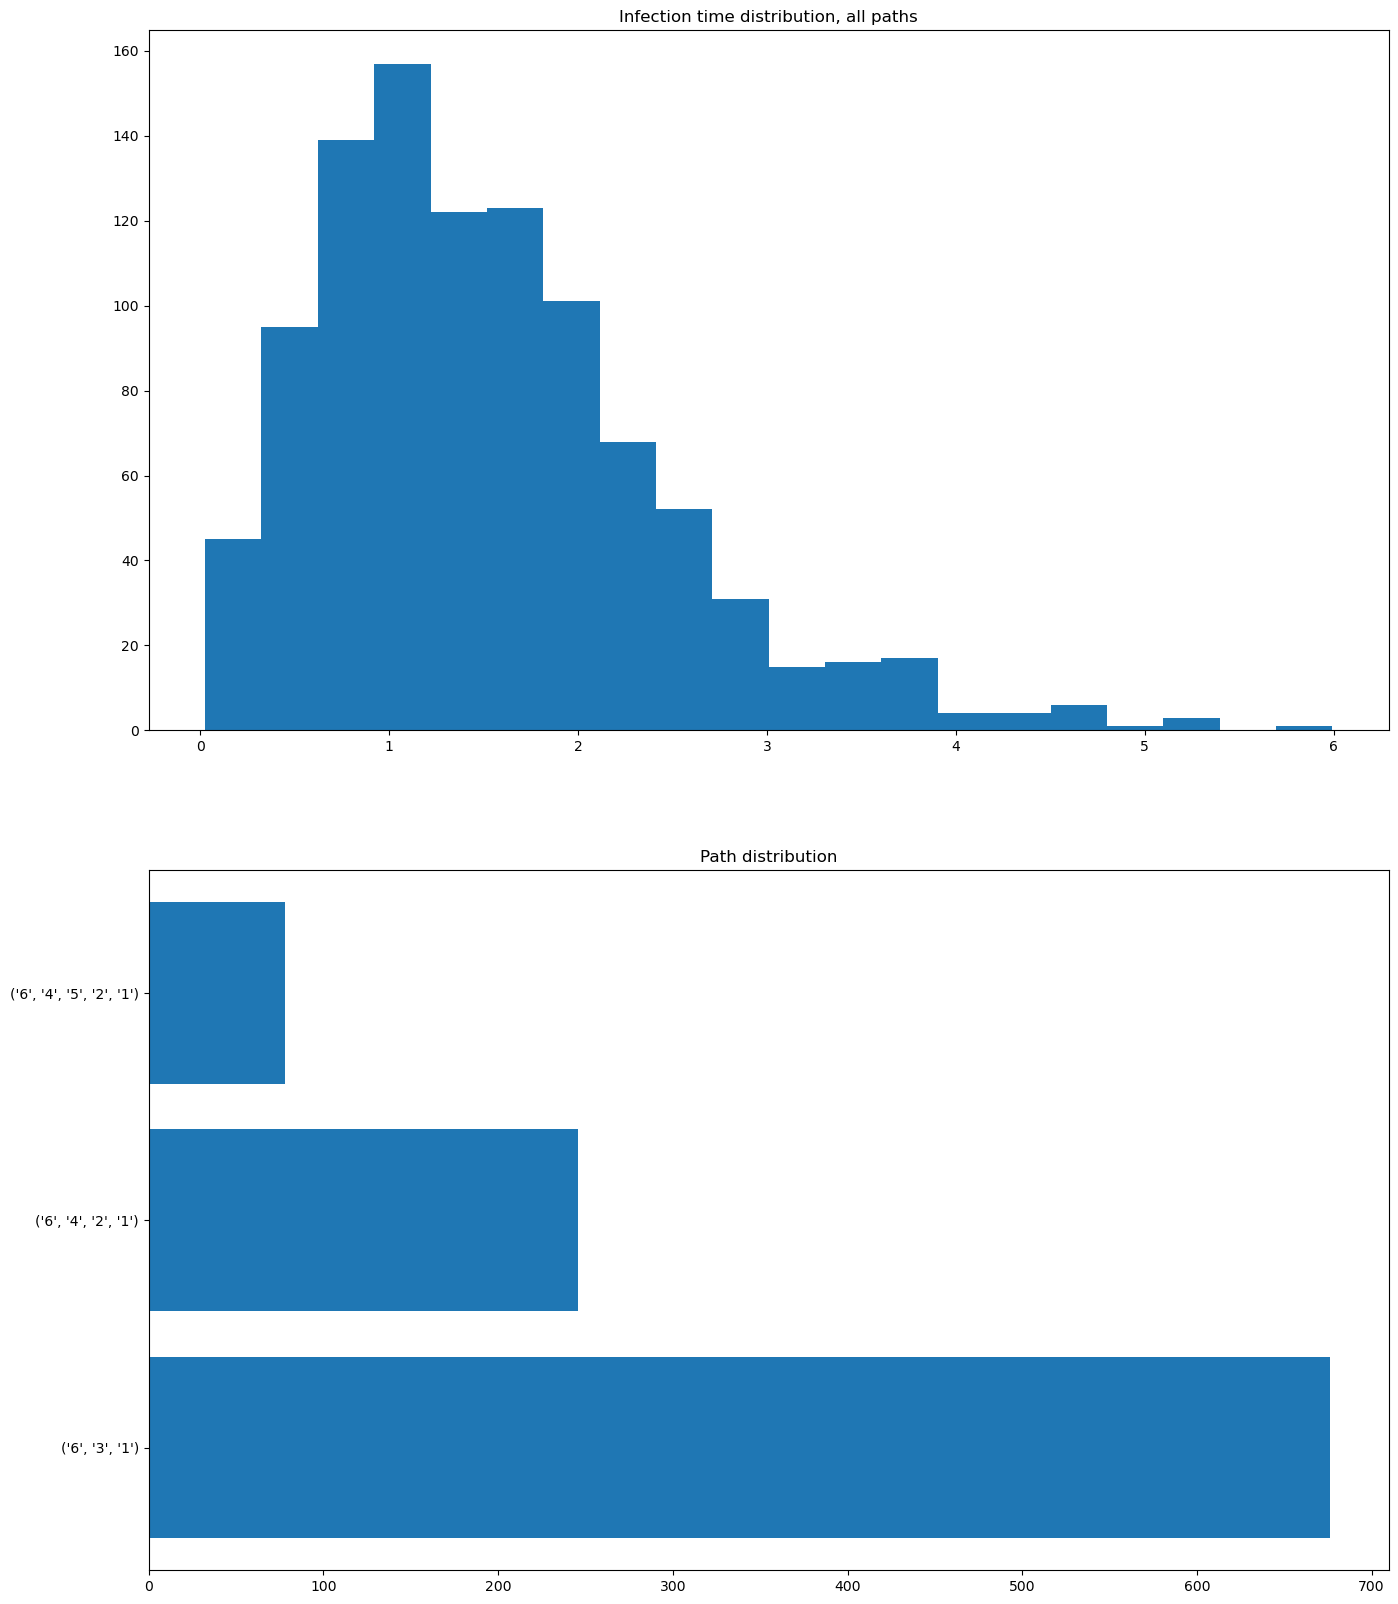

In [11]:
g.produce_histograms()
plt.show()

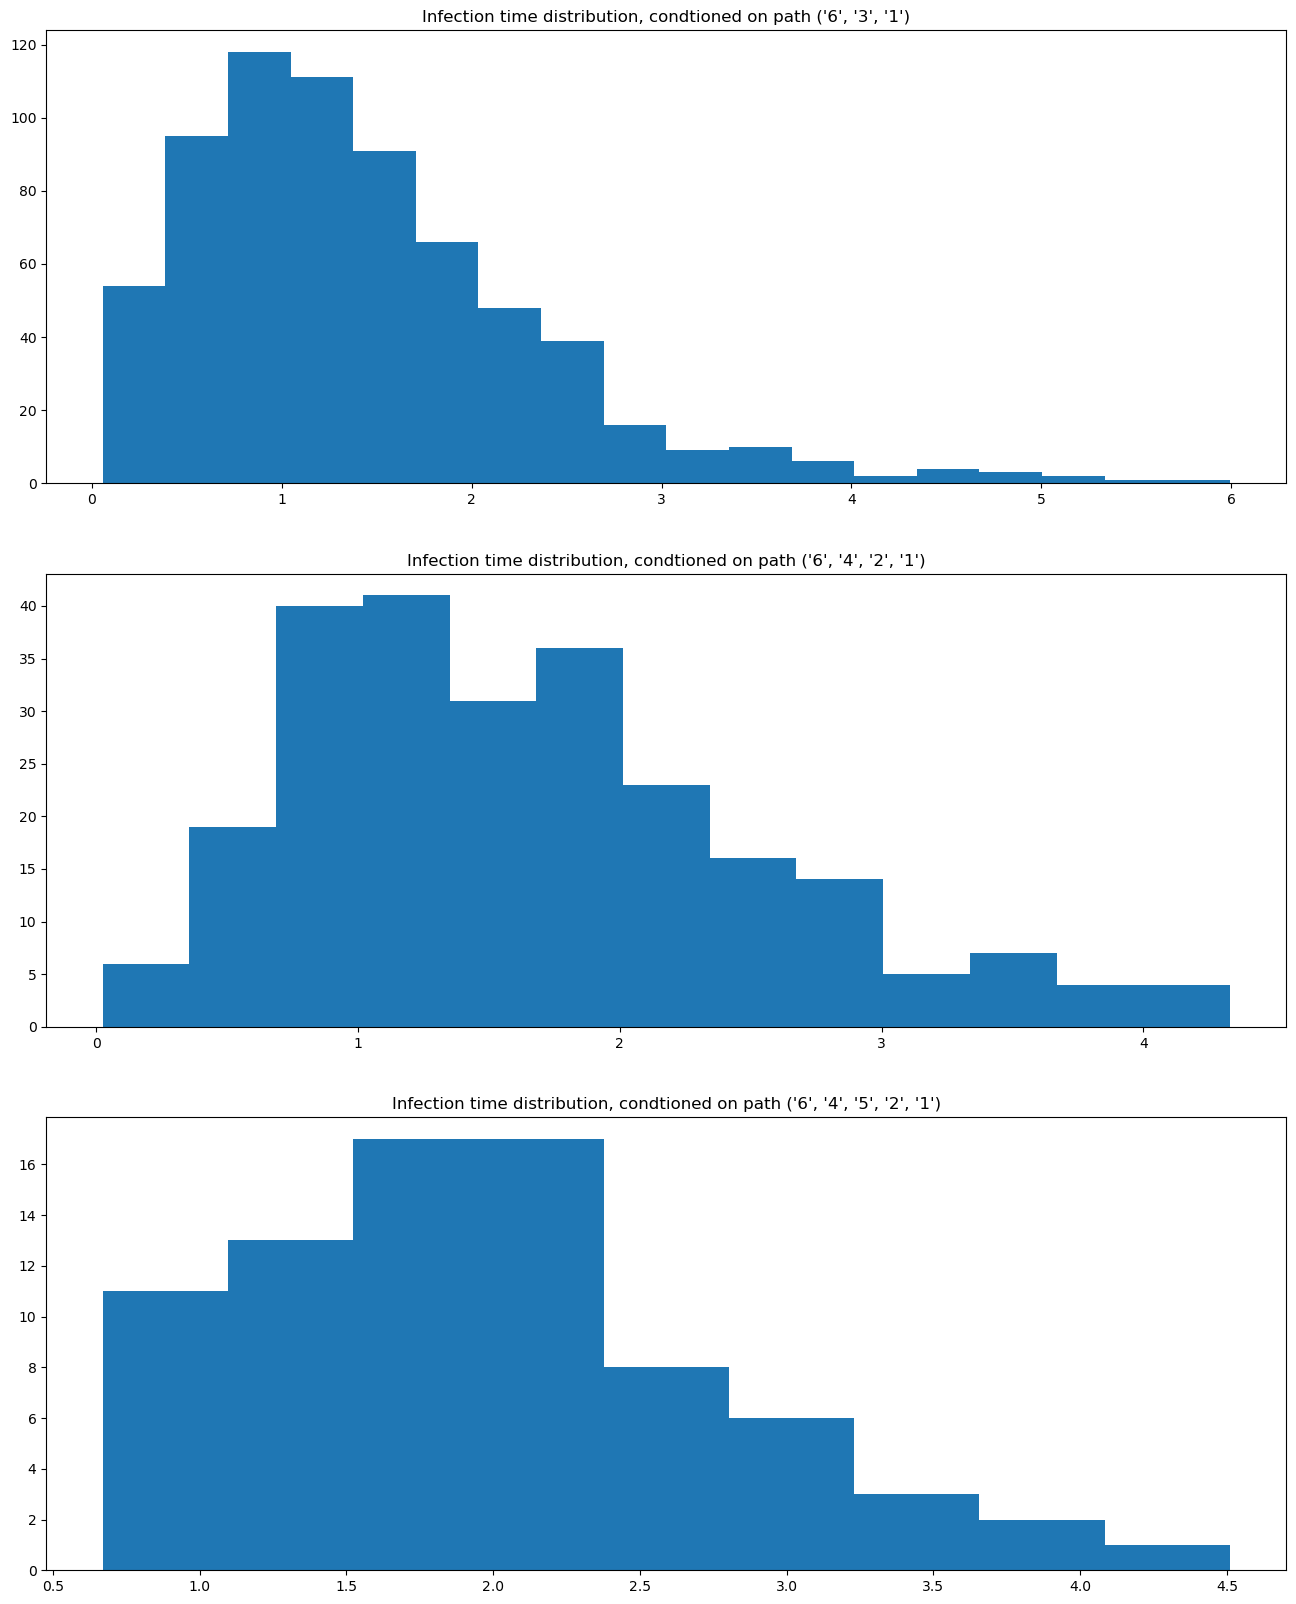

In [12]:
g.produce_extended_histograms()

In [13]:
h = Graph.erdos_renyi(7, 0.6, force_connection=True)
h.edge_set

{('0', '1', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('0', '2', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('0', '4', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('0', '6', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('1', '2', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('1', '5', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('1', '6', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('2', '4', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('2', '5', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('2', '6', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('3', '4', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('3', '6', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('4', '5', <scipy.stats._continuous_distns.expon_gen at 0x7f34eaa5a7b0>),
 ('4', '6', <scipy.stats.

In [14]:
h._adjency_matrix

,0,1,2,3,4,5,6
0,inf,<scipy...,<scipy...,inf,<scipy...,inf,<scipy...
1,<scipy...,inf,<scipy...,inf,inf,<scipy...,<scipy...
2,<scipy...,<scipy...,inf,inf,<scipy...,<scipy...,<scipy...
3,inf,inf,inf,inf,<scipy...,inf,<scipy...
4,<scipy...,inf,<scipy...,<scipy...,inf,<scipy...,<scipy...
5,inf,<scipy...,<scipy...,inf,<scipy...,inf,<scipy...
6,<scipy...,<scipy...,<scipy...,<scipy...,<scipy...,<scipy...,inf


In [15]:
h.reset_data()
h.reset_simulation()
h.simulate_gossip_rv('1','3')

np.float64(1.5266892676068196)

In [16]:
h.reset_data()
h.reset_simulation()
h.simulation_trial('0', '6', iters=100)
h.construct_path('0','6')

['6', '0']

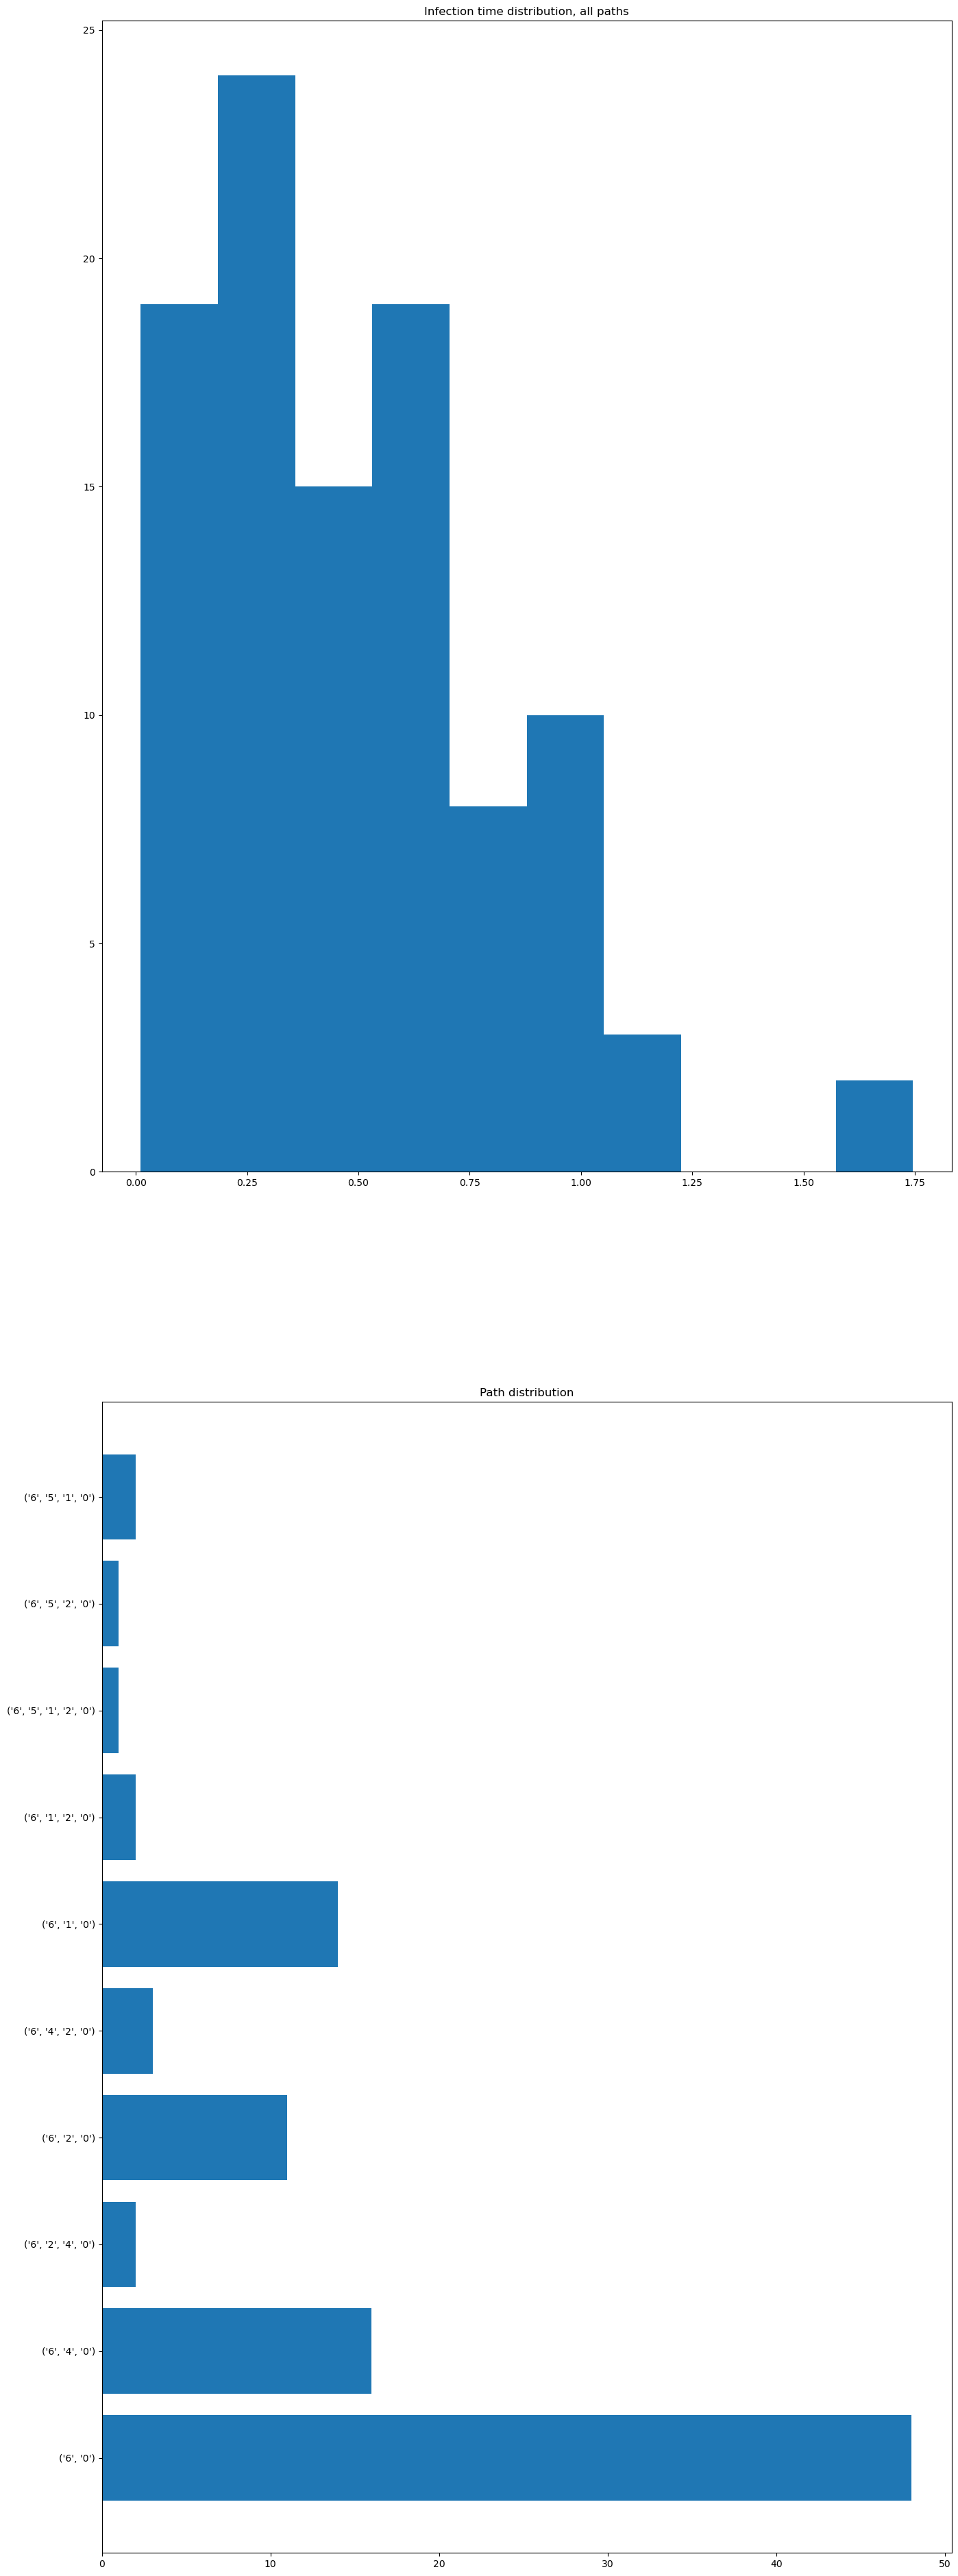

In [17]:
h.produce_histograms()

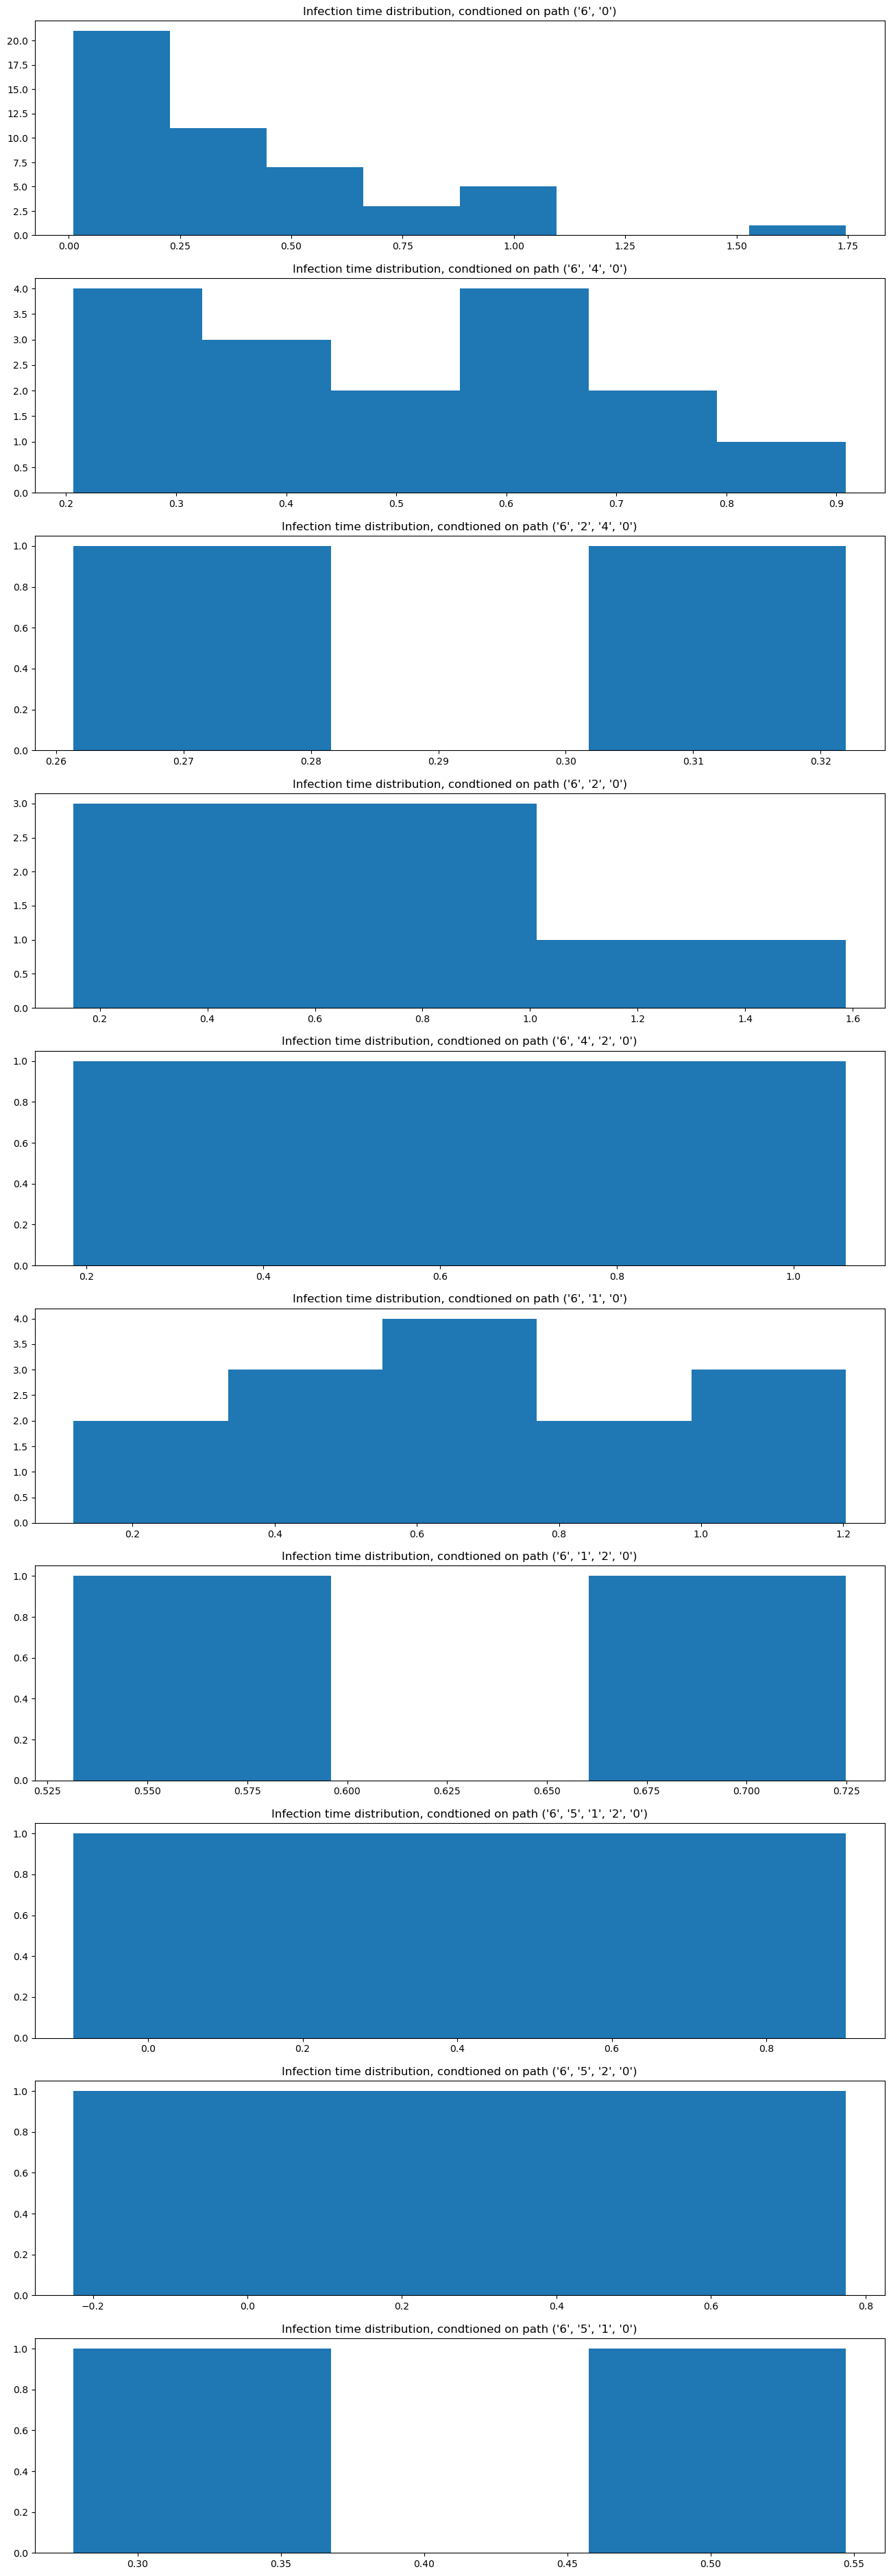

In [18]:
h.produce_extended_histograms()

In [19]:
data = Graph.erdos_renyi_simulation_trial(4, 0.7, '0', '3', iters=10)

In [20]:
data

(defaultdict(<function Graph.erdos_renyi_simulation_trial.<locals>.<lambda>()>,
             {('3', '0'): 6,
              ('3', '1', '2', '0'): 1,
              ('3', '2', '1', '0'): 1,
              ('3', '1', '0'): 1,
              ('3', '2', '0'): 1}),
 defaultdict(list,
             {('3', '0'): [np.float64(0.056162240266073825),
               np.float64(0.34012233149519416),
               np.float64(1.7021655542518035),
               np.float64(1.4895281209838436),
               np.float64(0.24010302722006302),
               np.float64(0.9180679057473111)],
              ('3', '1', '2', '0'): [np.float64(0.8571704190915634)],
              ('3', '2', '1', '0'): [np.float64(1.2677395279230976)],
              ('3', '1', '0'): [np.float64(1.2926740205131497)],
              ('3', '2', '0'): [np.float64(0.7332220628096134)]}))

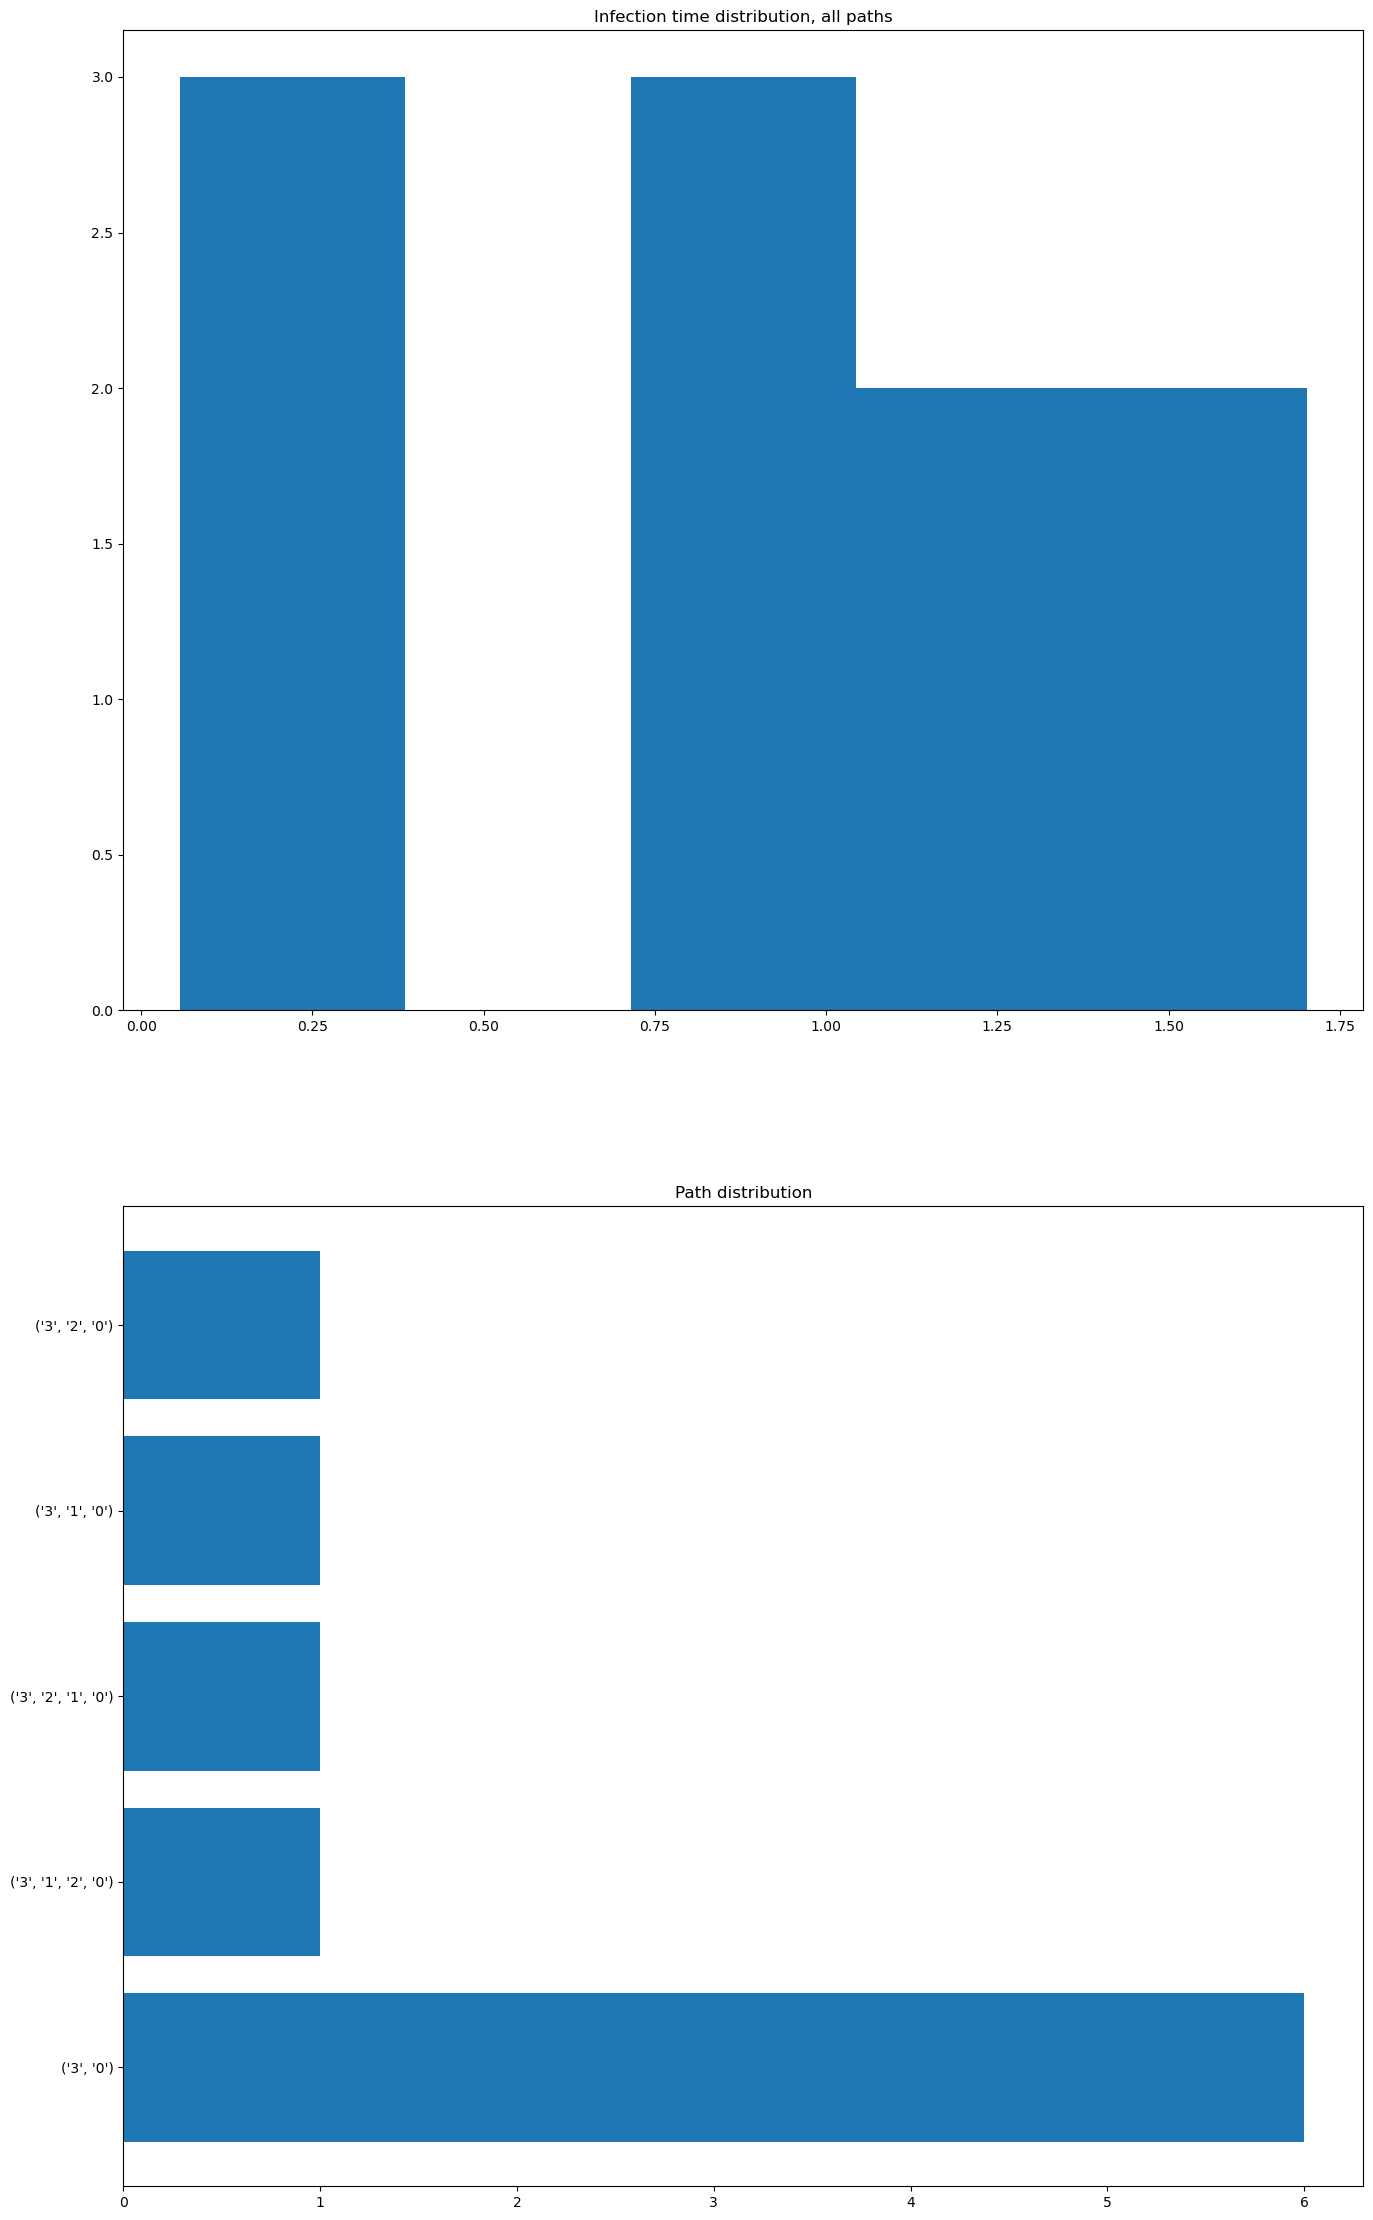

In [21]:
Graph.produce_histograms(data[0],data[1])

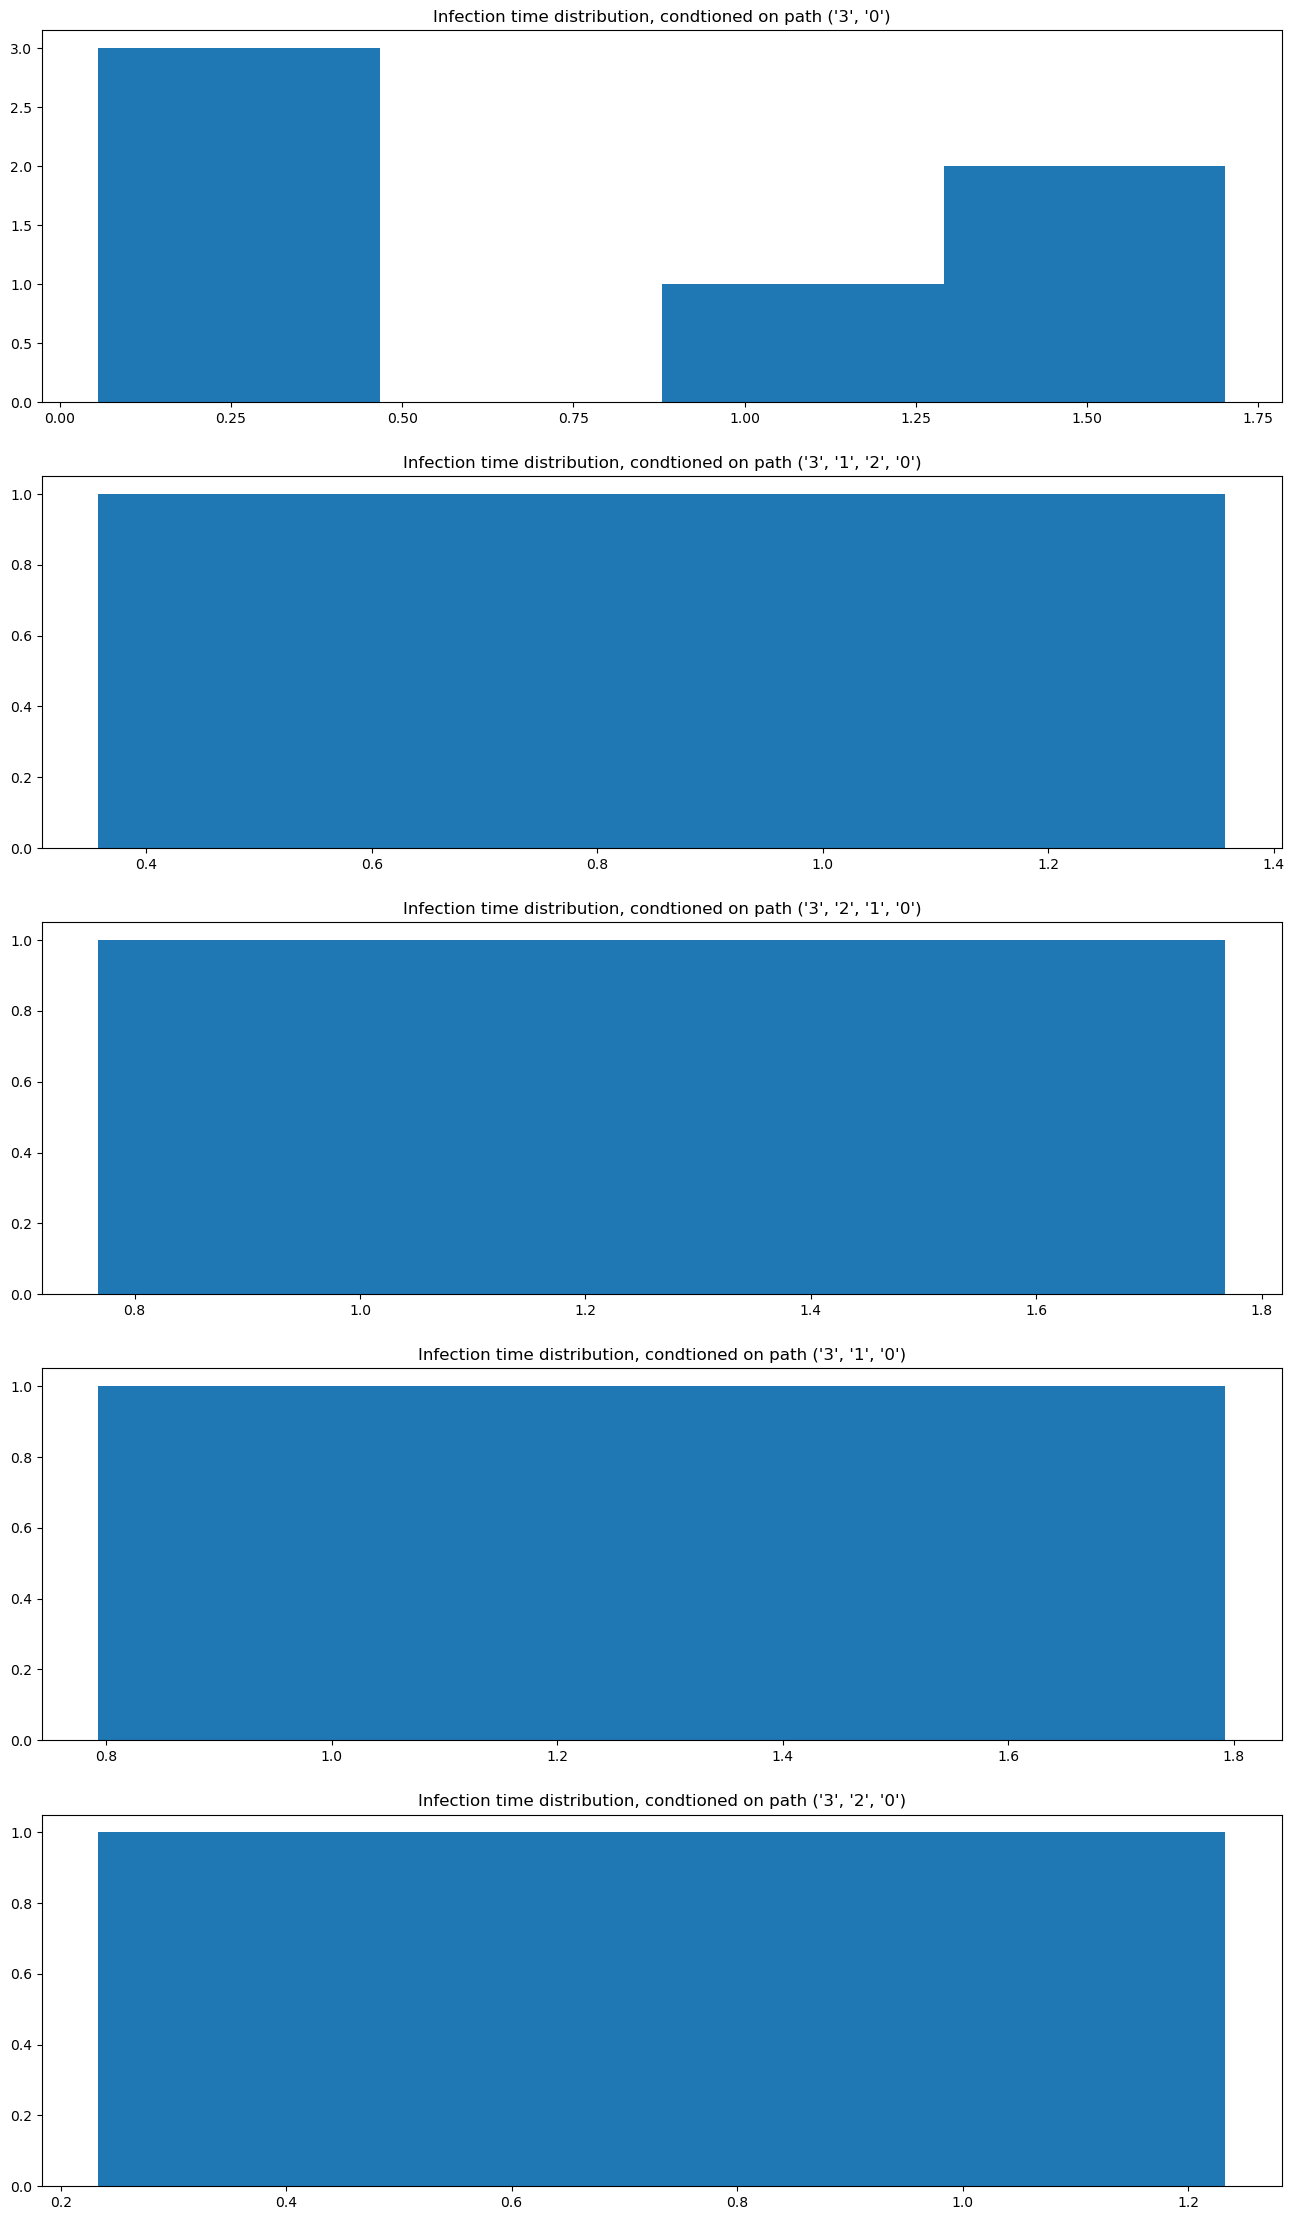

In [22]:
Graph.produce_extended_histograms(data[0],data[1])

# is_connected benchmarking

In [ ]:
# Connection function
c1_times = []
c2_times = []
for _ in range(10):
    h = Graph.erdos_renyi(100, 0.9)
    t0 = time.time()
    _ = h.is_connected()
    t1 = time.time()
    c1_times.append(t1-t0)
    t0 = time.time()
    _ = h.is_connected_laplacian()
    t1 = time.time()
    c2_times.append(t1-t0)

c1_times = np.array(c1_times)
c2_times = np.array(c2_times)
print(f"First connection function avg time: {c1_times.mean()}")
print(f"Second connection function avg time: {c2_times.mean()}")

First connection function avg time: 0.0028364181518554686
Second connection function avg time: 0.024653697013854982


It appears calculating laplacian is ~10x shower than just using bfs, speculate this is due to using pandas as the data structure and possible data copying. Consistently ~10x slower